## **Analiza sygnału EKG**
### Autorzy: Jakub Grobelny (252849), Zuzanna Rykaczewska (251275)

#### 1. Wczytywanie danych i wstępna analiza sygnału

In [94]:
import pandas as pd

with open('normal_small.xlsx', 'rb') as file:
    data = pd.read_excel(file, skiprows=1).astype(float).values

df = pd.DataFrame(data)
df.columns = ['Time', 'Voltage [mV]']
df.index = df.index + 1
df.head()

,Time,Voltage [mV]
1,0.007989,-0.435
2,0.011984,-0.392
3,0.015979,-0.394
4,0.019973,-0.376
5,0.023968,-0.414


In [95]:
# Wyliczenie fs
delta_t = df["Time"].diff().mean()
fs = 1 / delta_t
print(f"Częstotliwość próbkowania wynosi: {round(fs, 0)} [Hz]")

Częstotliwość próbkowania wynosi: 250.0 [Hz]


### Analiza częstotliwości składowych (FFT)

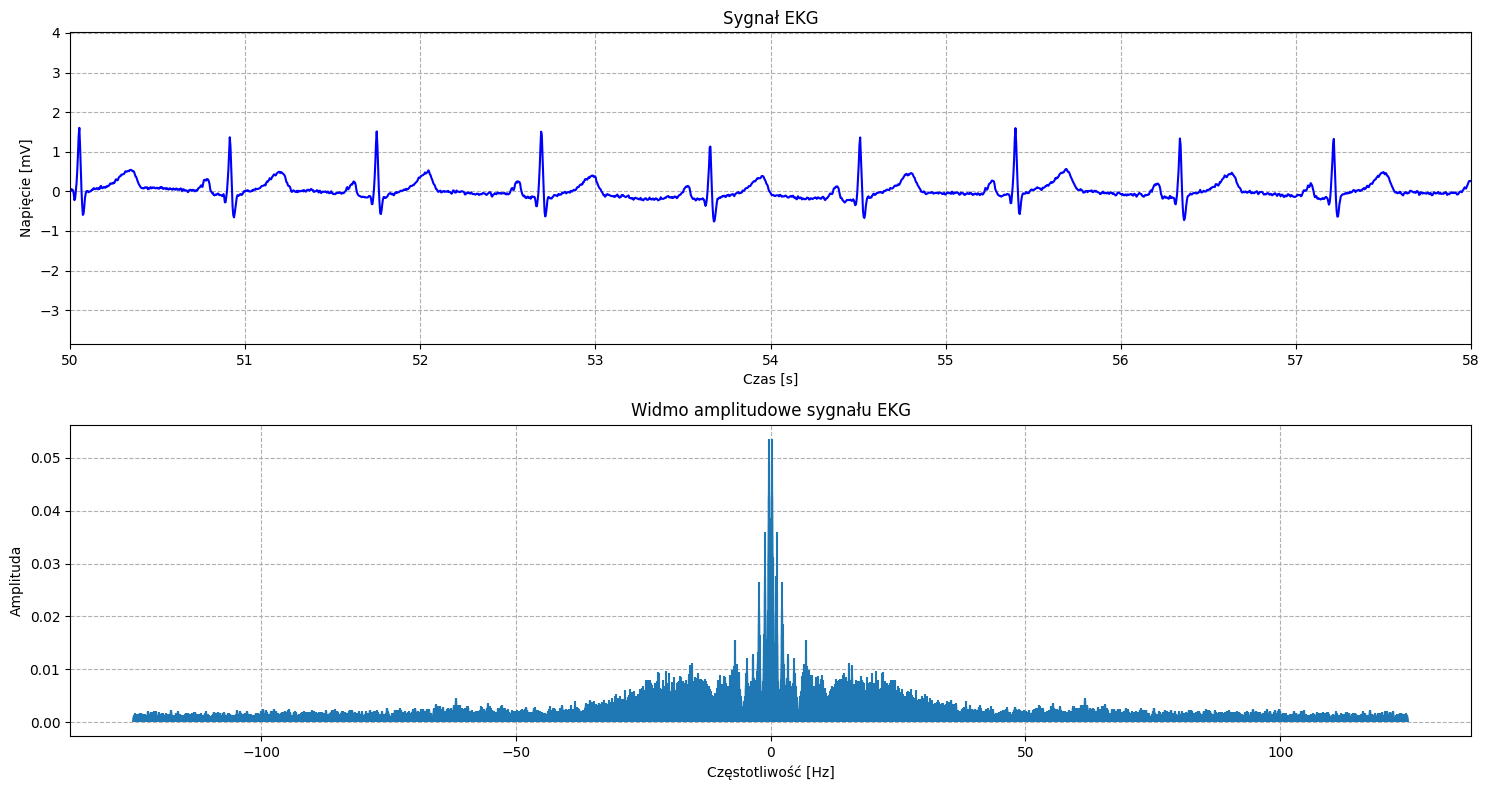

In [96]:
import matplotlib.pyplot as plt
from matplotlib.offsetbox import AnchoredText
import numpy as np

def fft_signal_plot(signal, t, fs, title, fft_title):
    # Wyliczanie fft
    n = len(signal)
    delta_t = 1.0 / fs
    fft_values = np.fft.fft(signal)
    freq = np.fft.fftfreq(n, d=delta_t)
    amplitude = np.abs(fft_values) * (2.0 / n)
    
    # Wykres sygnału i jego widma
    fig, ax = plt.subplots(2, 1, figsize=(15, 8))

    ax[0].plot(t, signal, color='blue')
    ax[0].set_title(title)
    ax[0].set_xlabel('Czas [s]')
    ax[0].set_xlim(50, 58)
    ax[0].set_ylabel('Napięcie [mV]')
    ax[0].grid(linestyle='--')

    ax[1].stem(freq, amplitude, linefmt='-', markerfmt=' ', basefmt=' ')
    ax[1].set_title(fft_title)
    ax[1].set_xlabel('Częstotliwość [Hz]')
    ax[1].set_ylabel('Amplituda')
    ax[1].grid(linestyle='--')

    plt.tight_layout()

# Wykres dla surowego sygnału EKG i jego widma
fft_signal_plot(df["Voltage [mV]"].values, df["Time"].values, fs=250, title="Sygnał EKG", fft_title="Widmo amplitudowe sygnału EKG")

## Preprocesing

##### 1. Usunięcie dryftu (Baseline)

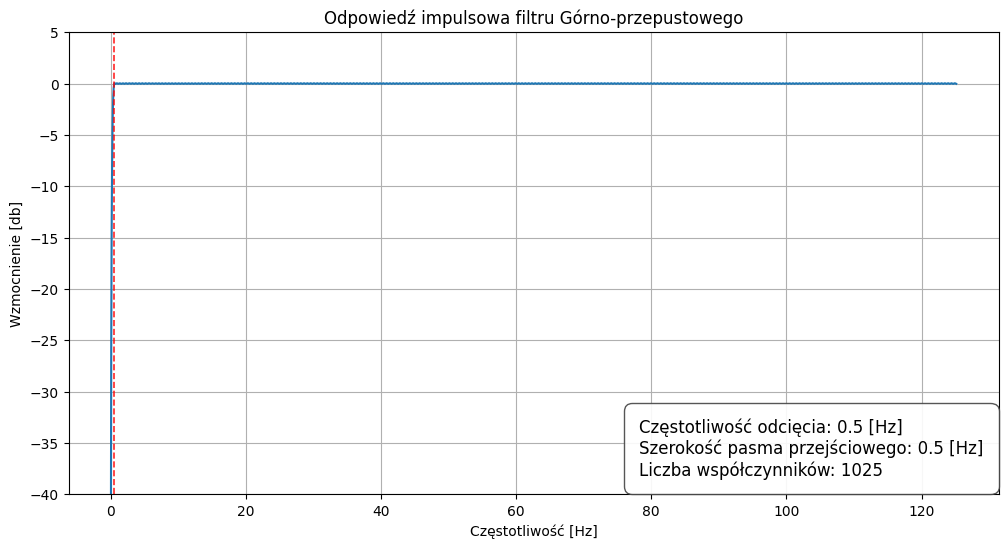

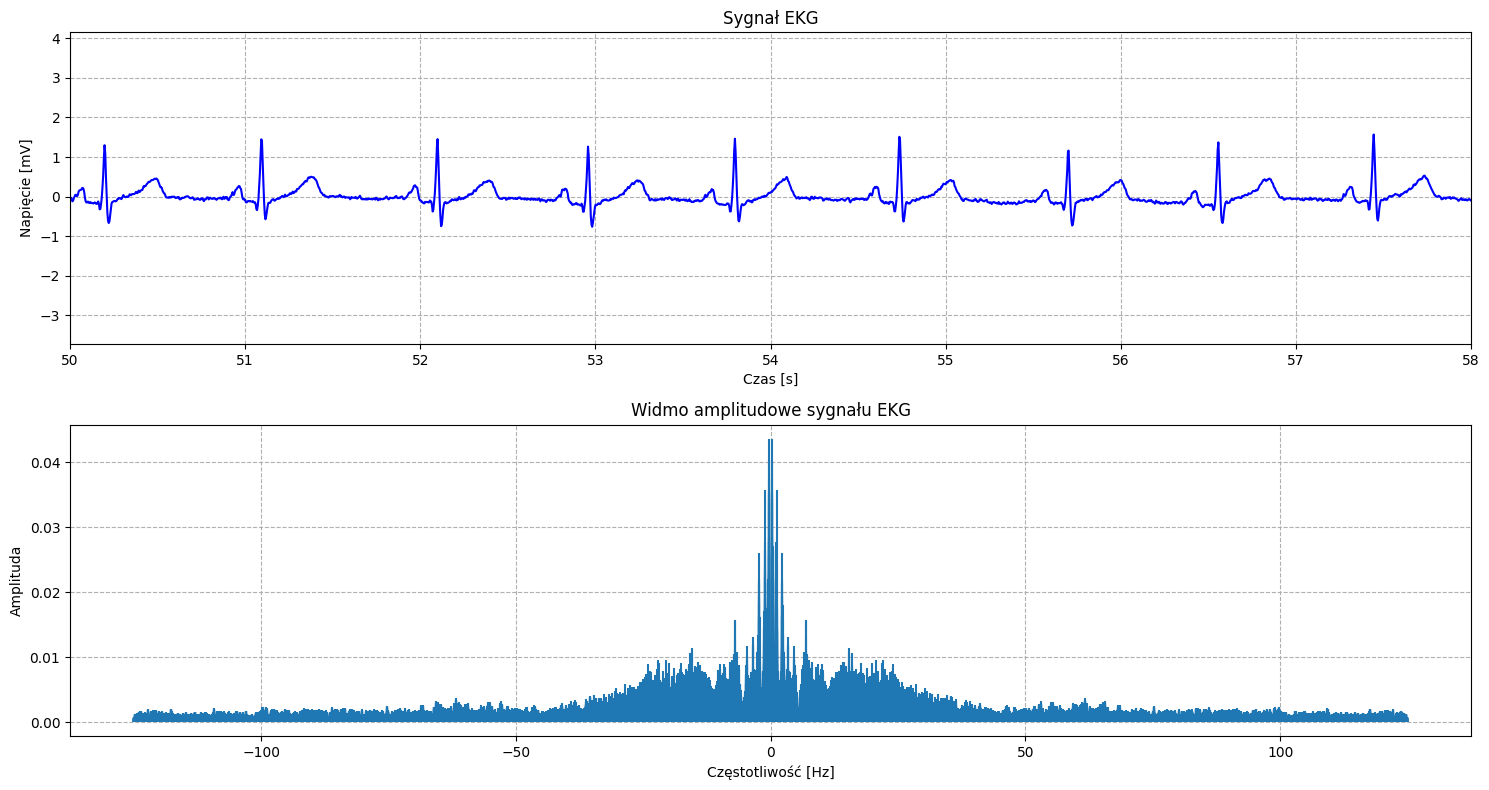

In [97]:
from scipy import signal

def odpowiedz_impulsowa_fir(w, h, title, fs_cut, txt):
    txt = str(txt)

    fig = plt.figure(figsize=(12, 6))
    ax = fig.add_subplot(111)
    ax.plot(w, 20*np.log10(np.abs(h)))
    ax.set_ylim(-40, 5)
    ax.grid(True)
    ax.set_xlabel('Częstotliwość [Hz]')
    ax.set_ylabel('Wzmocnienie [db]')
    ax.set_title(title)
    ax.axvline(fs_cut, color='red', ls='--', lw=1.2, alpha=0.85)

    # Opis filtru
    at = AnchoredText(txt, loc='lower right', prop=dict(size=12), frameon=True)
    at.patch.set_boxstyle("round,pad=0.5")
    at.patch.set_facecolor("white")
    at.patch.set_alpha(0.9)
    at.patch.set_edgecolor("#444")
    ax.add_artist(at)
    plt.show()

hpf_cutoff = 0.5
hpf_trans_width = 0.5
hpf_numtaps = 1025
taps = signal.remez(
    hpf_numtaps,
    [0.0, hpf_cutoff - hpf_trans_width, hpf_cutoff, 0.5 * fs], 
    [0, 1],                       
    fs=fs                         
)

w_hp, h_hp = signal.freqz(taps, [1.0], worN=4096, fs=fs)

odpowiedz_impulsowa_fir(w_hp, h_hp, 'Odpowiedź impulsowa filtru Górno-przepustowego', hpf_cutoff,
                        f"Częstotliwość odcięcia: {hpf_cutoff} [Hz]\nSzerokość pasma przejściowego: {hpf_trans_width} [Hz]\nLiczba współczynników: {hpf_numtaps}")
hp_filtred_signal = signal.lfilter(taps, [1.0], df["Voltage [mV]"].values) # Odfiltrowany sygnał

# Wyniki po filtracji
fft_signal_plot(hp_filtred_signal, df["Time"].values, fs=250, title="Sygnał EKG", fft_title="Widmo amplitudowe sygnału EKG")

#### 2. Usinięcie szumu szumu wynikającego z interferencji lini energetycznych

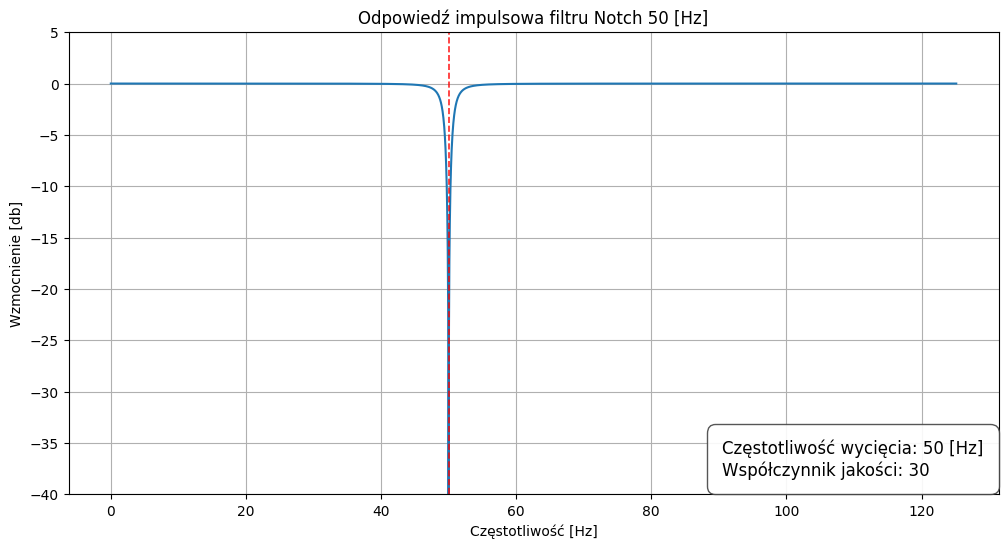

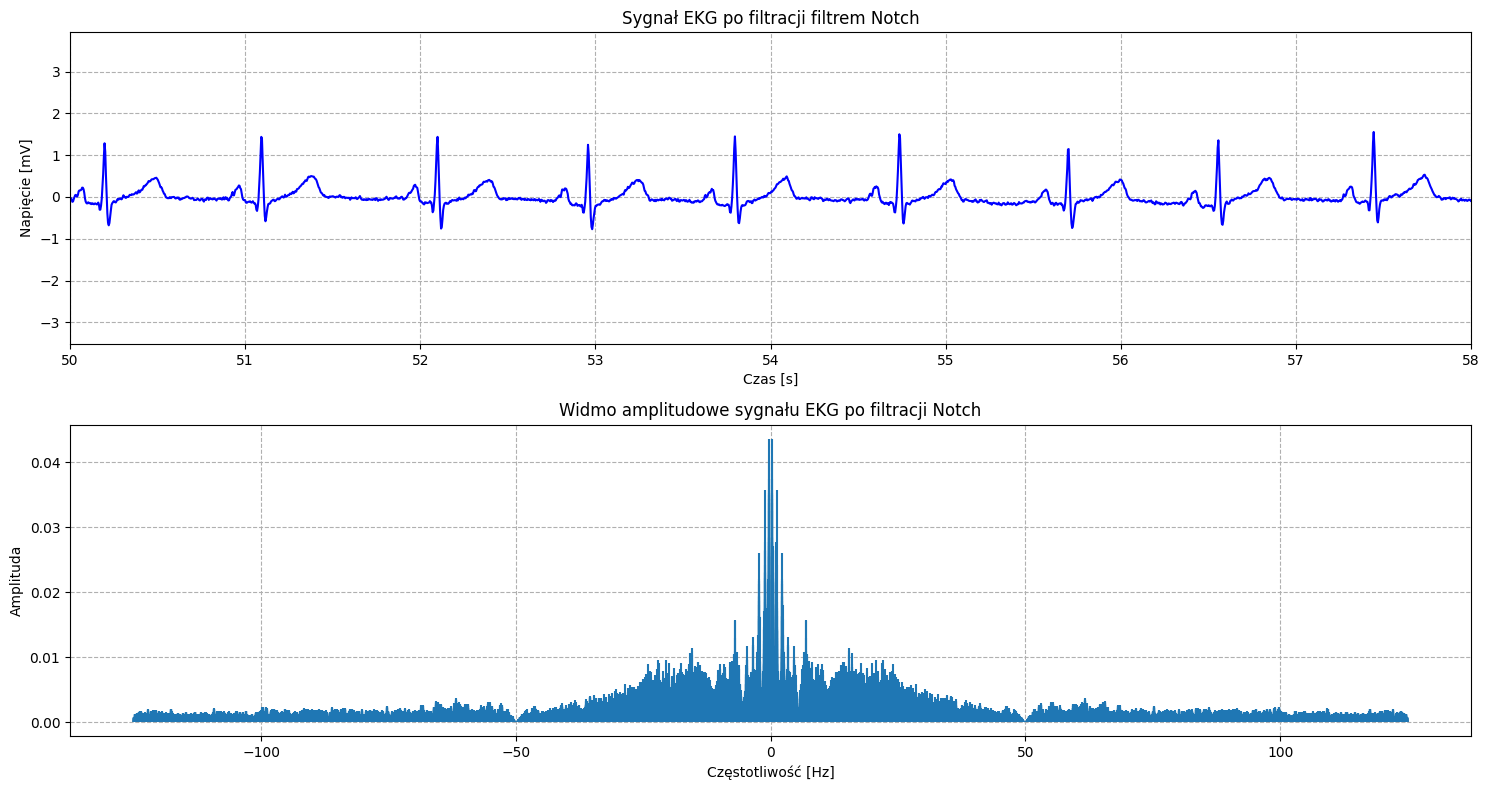

In [ ]:
center_freq = 50
Q = 30

b_notch, a_notch = signal.iirnotch(center_freq, Q, fs)
w_notch, h_notch = signal.freqz(b_notch, a_notch, worN=4096, fs=fs)

odpowiedz_impulsowa_fir(w_notch, h_notch, 'Odpowiedź impulsowa filtru Notch 50 [Hz]', center_freq,
                        f"Częstotliwość wycięcia: {center_freq} [Hz]\nWspółczynnik jakości: {Q}")

notch_filtred_signal = signal.filtfilt(b_notch, a_notch, hp_filtred_signal)
fft_signal_plot(notch_filtred_signal, df["Time"].values, fs=250, title="Sygnał EKG po filtracji filtrem Notch", fft_title="Widmo amplitudowe sygnału EKG po filtracji Notch")

#### 3. Redukcja szumów wysokoczęstotliwościowych

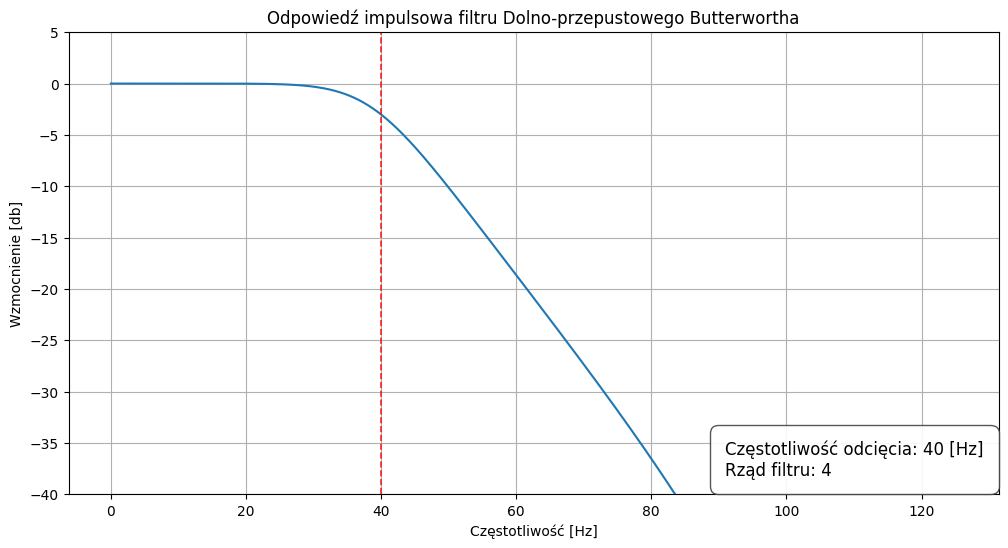

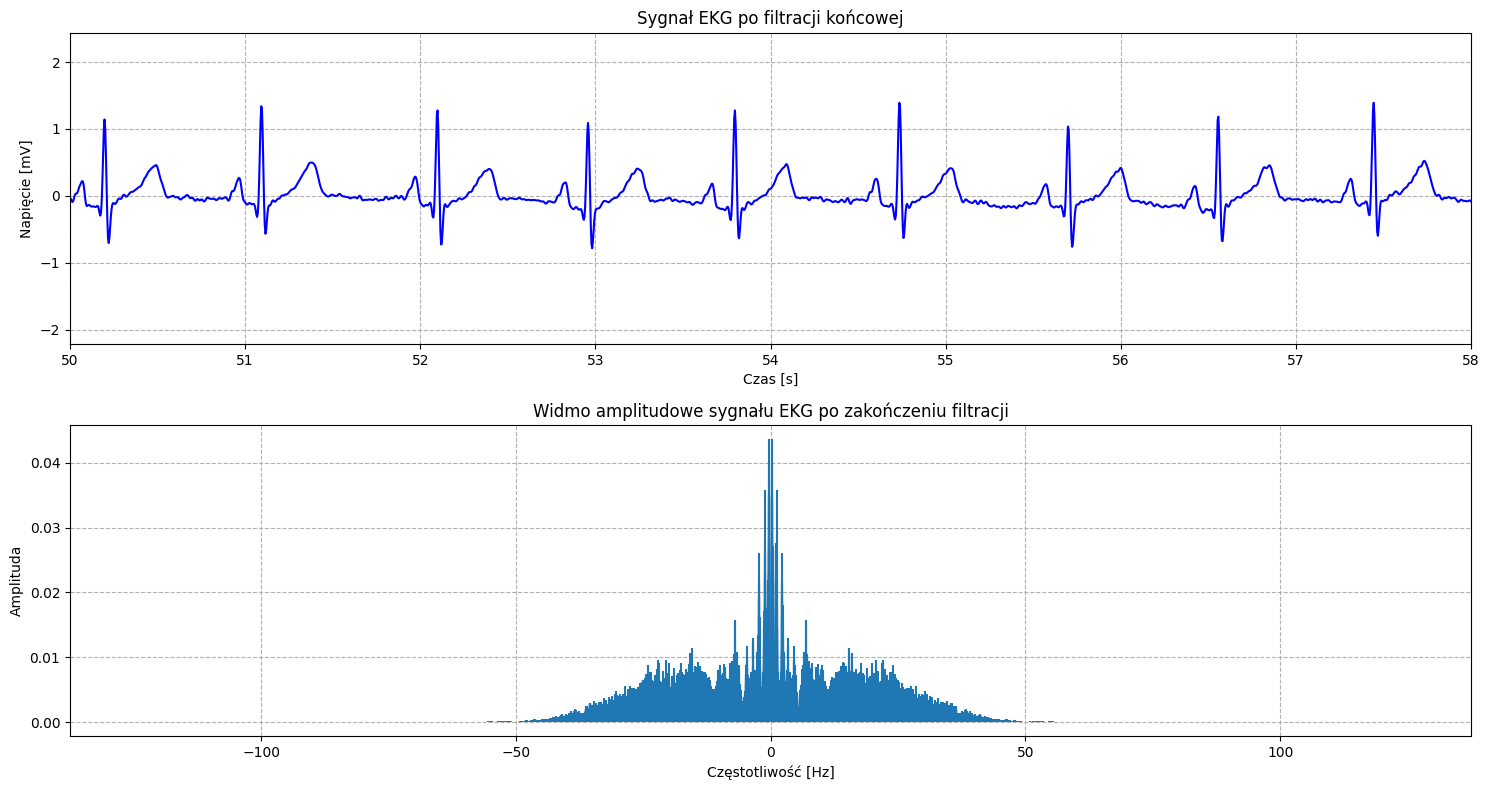

In [101]:
lpf_cutoff = 40
lpf_order = 4

b_lpf, a_lpf = signal.butter(lpf_order, lpf_cutoff/(fs/2), btype='low', analog=False)
w_lpf, h_lpf = signal.freqz(b_lpf, a_lpf, worN=4096, fs=fs)

odpowiedz_impulsowa_fir(w_lpf, h_lpf, 'Odpowiedź impulsowa filtru Dolno-przepustowego Butterwortha', lpf_cutoff,
                        f"Częstotliwość odcięcia: {lpf_cutoff} [Hz]\nRząd filtru: {lpf_order}")

lpf_filtred_signal = signal.filtfilt(b_lpf, a_lpf, notch_filtred_signal) # Filtracja końcowa
fft_signal_plot(lpf_filtred_signal, df["Time"].values, fs=250, title="Sygnał EKG po filtracji końcowej", fft_title="Widmo amplitudowe sygnału EKG po zakończeniu filtracji")

## Analiza sygnału

(50.0, 58.0)

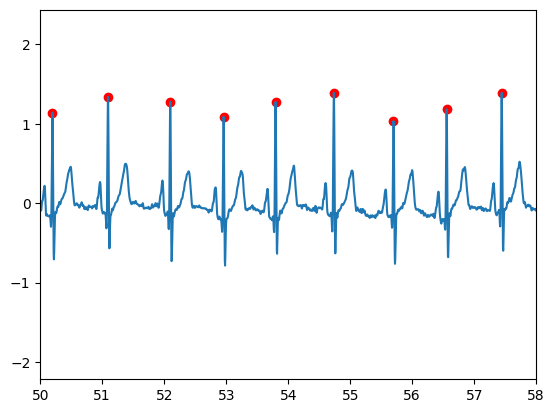

In [ ]:
r_peaks = signal.find_peaks(lpf_filtred_signal, distance=fs*0.6)[0]

plt.figure()
plt.plot(df["Time"].values, lpf_filtred_signal, label='Sygnał EKG po filtracji')
plt.scatter(df["Time"].values[r_peaks], lpf_filtred_signal[r_peaks], color='red', label='R-peaks')
plt.xlim(50, 58)